### makemore
- makes more of things that you give it
- makemore is a character-level language model, it knows how to predict the next character in the sequence
- invlove a lot of networks, such as Bigram, Bag of Words, MLP, RNN, GRU, Transformer

In [1]:
words = open("names.txt").read().splitlines()

In [2]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
len(words)

32033

In [4]:
min(len(word) for word in words)

2

- a character-level language model is predicting the next character in a sequence given already some concrete sequence of characters before it

- first implement: bigram
- always working with just two characters at a time
- modeling a kind of a little local structure

In [8]:
for w in words[:1]:
    for ch1, ch2 in zip(w,w[1:]):
        print(ch1, ch2)

e m
m m
m a


In [13]:
b = {}

for w in words[:3]:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs,chs[1:]):
        biagram = (ch1, ch2)
        b[biagram] = b.get(biagram, 0) + 1
        print(ch1, ch2)

<S> e
e m
m m
m a
a <E>
<S> o
o l
l i
i v
v i
i a
a <E>
<S> a
a v
v a
a <E>


In [14]:
b

{('<S>', 'e'): 1,
 ('e', 'm'): 1,
 ('m', 'm'): 1,
 ('m', 'a'): 1,
 ('a', '<E>'): 3,
 ('<S>', 'o'): 1,
 ('o', 'l'): 1,
 ('l', 'i'): 1,
 ('i', 'v'): 1,
 ('v', 'i'): 1,
 ('i', 'a'): 1,
 ('<S>', 'a'): 1,
 ('a', 'v'): 1,
 ('v', 'a'): 1}

In [16]:
b = {}

for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs,chs[1:]):
        biagram = (ch1, ch2)
        b[biagram] = b.get(biagram, 0) + 1

In [17]:
sorted(b.items(), key = lambda kv:kv[1], reverse = True)

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [18]:
import torch


In [30]:
N = torch.zeros((28,28), dtype = torch.int32)

In [31]:
chars = sorted(list(set(''.join(words)))) # because of set
stoi = {s:i for i,s in enumerate(chars)}
stoi['<S>'] = 26
stoi['<E>'] = 27

In [32]:
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs,chs[1:]):
        stoi1 = stoi[ch1]
        stoi2 = stoi[ch2]
        N[stoi1,stoi2] += 1

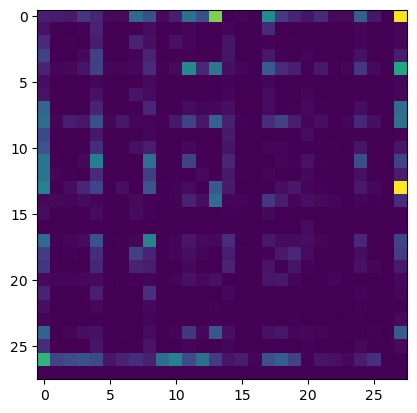

In [36]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N)

In [39]:
itos = {i:s for s,i in stoi.items()}

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

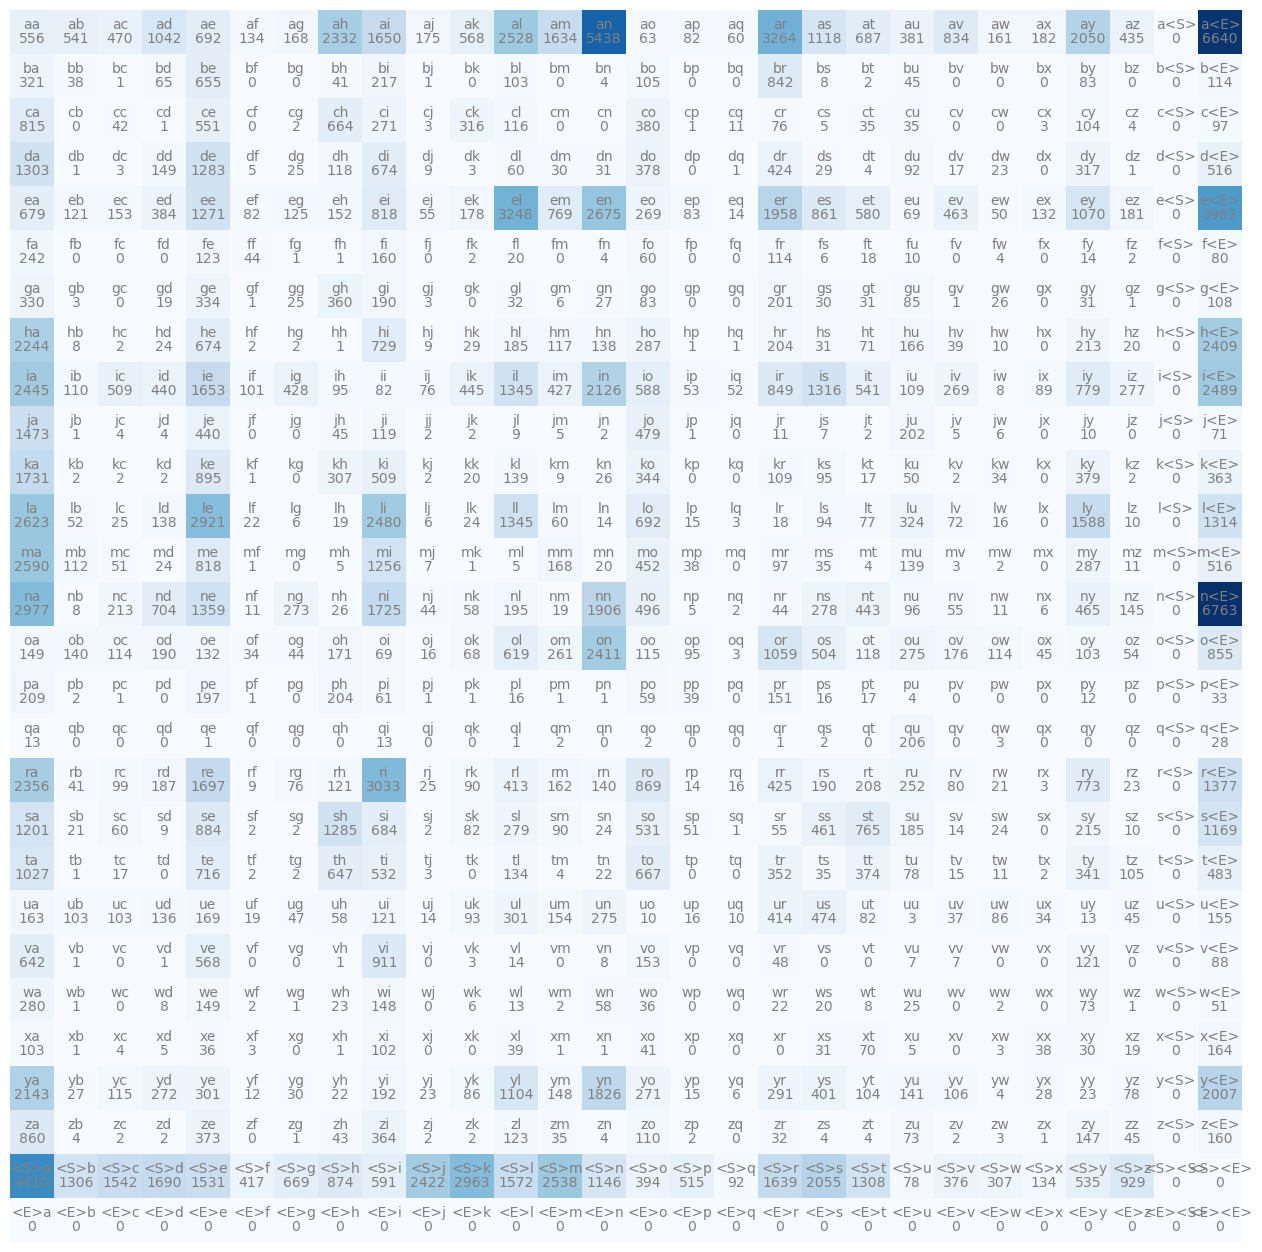

In [41]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize = (16,16))
plt.imshow(N, cmap="Blues")
for i in range(28):
    for j in range(28):
        chstr = itos[i] + itos[j]
        plt.text(j,i, chstr, ha='center', va='bottom', color='gray')
        plt.text(j,i,N[i,j].item(),ha='center',va='top',color='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

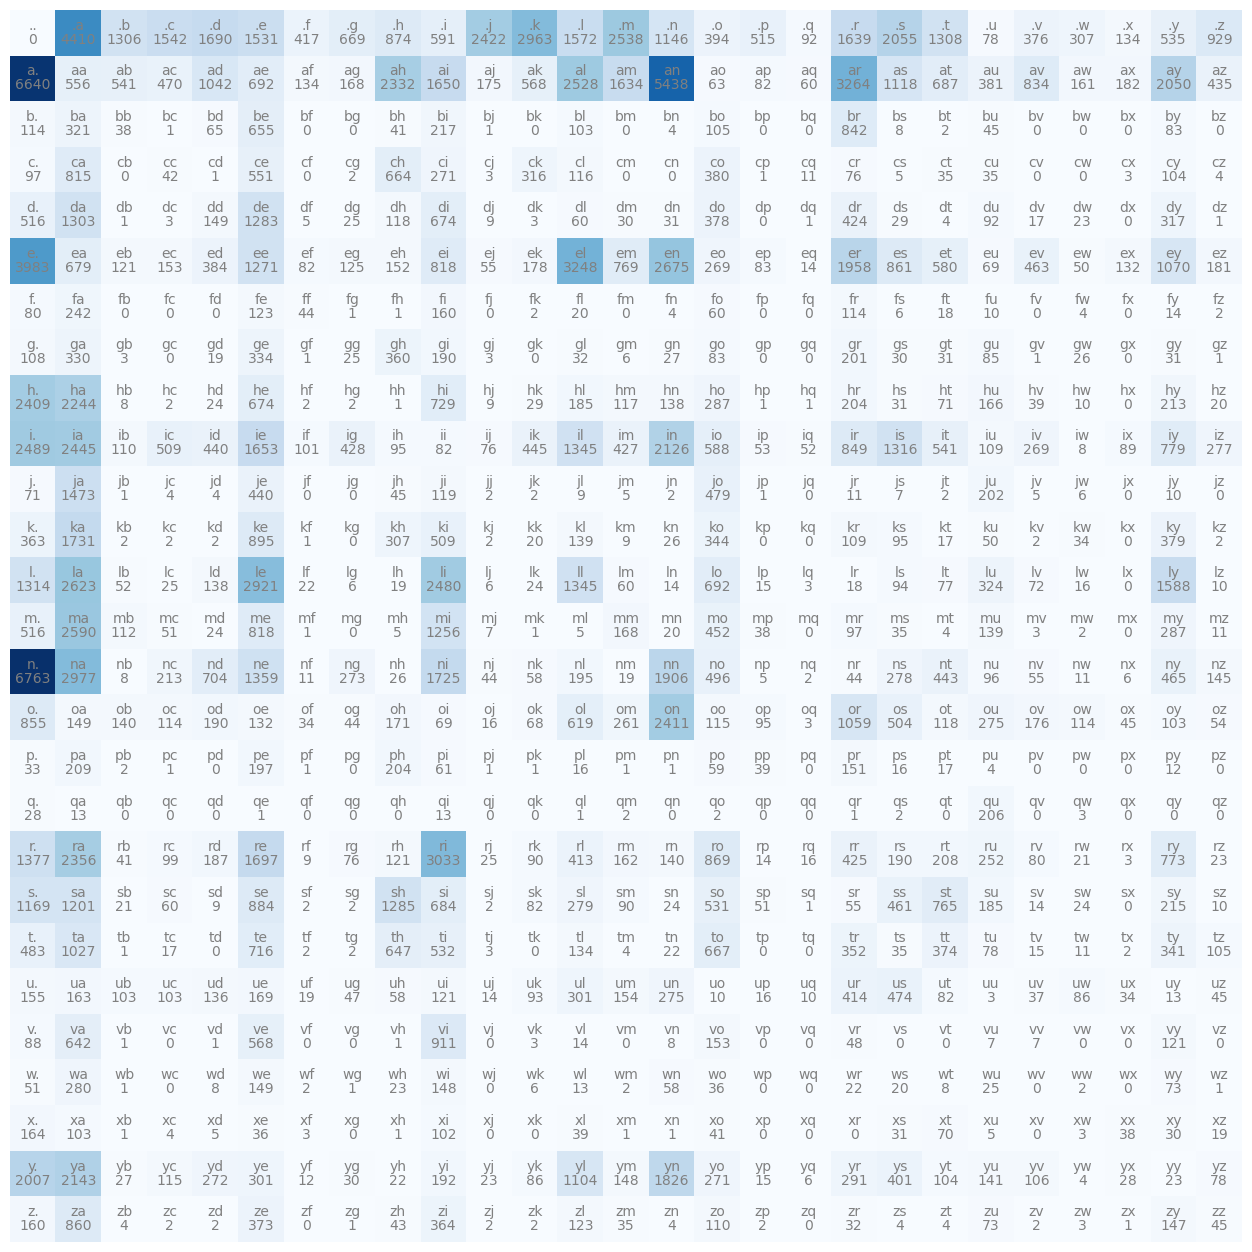

In [44]:
N = torch.zeros((27,27), dtype = torch.int32)

chars = sorted(list(set(''.join(words)))) # because of set
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

itos = {s:i for i,s in stoi.items()}

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        stoi1 = stoi[ch1]
        stoi2 = stoi[ch2]
        N[stoi1,stoi2] += 1

import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize = (16,16))
plt.imshow(N, cmap="Blues")
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j,i, chstr, ha='center', va='bottom', color='gray')
        plt.text(j,i,N[i,j].item(),ha='center',va='top',color='gray')
plt.axis('off')

In [47]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [ ]:
# use generator 
g = torch.Generator().manual_seed(123)
torch.multinomial(p, num_samples=20, replacement=True, generator=g) # replacement=True means one variable can be drawed again

tensor([ 8,  1, 12,  1, 10, 11, 12, 11, 23,  1, 19,  1,  3,  3,  3, 10, 15,  5,
        12,  3])

In [54]:
P = N.float()
P = P / P.sum(dim=1,keepdim=True)

In [ ]:
g = torch.Generator().manual_seed(123)

for i in range(10):
    out = []
    idx = 0
    while True:
        # p = N[idx].float()
        # p = p / p.sum()
        p = P[idx]
        idx = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[idx])
        if idx == 0:
            break
    out = ''.join(out)
    print(out)

ayl.
eeiey.
viannalizyr.
pidouyra.
jon.
cerrdyanaya.
kseli.
peyussmon.
zzolie.
e.


In [63]:
# use the log-likelihood to evaluate the network
log_likelihood = 0.0
# normalize
n = 0

for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        stoi1 = stoi[ch1]
        stoi2 = stoi[ch2]
        prob = P[stoi1,stoi2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'log_likelihoood={log_likelihood:.4f}')
nll = -log_likelihood
print(f'nll={nll / n:.4f}')

.e: 0.0478 -3.0408
em: 0.0377 -3.2793
mm: 0.0253 -3.6772
ma: 0.3899 -0.9418
a.: 0.1960 -1.6299
.o: 0.0123 -4.3982
ol: 0.0780 -2.5508
li: 0.1777 -1.7278
iv: 0.0152 -4.1867
vi: 0.3541 -1.0383
ia: 0.1381 -1.9796
a.: 0.1960 -1.6299
.a: 0.1377 -1.9829
av: 0.0246 -3.7045
va: 0.2495 -1.3882
a.: 0.1960 -1.6299
log_likelihoood=-38.7856
nll=2.4241


In [ ]:
# model smoothing 
# avoid the phenomenon that some sisutuation's prob is inf
P = (N+1).float()
P = P / P.sum(dim=1,keepdim=True)


# use the log-likelihood to evaluate the network
log_likelihood = 0.0
# normalize
n = 0

for w in ['andrejq']: # original prob of 'jq' = 0
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        stoi1 = stoi[ch1]
        stoi2 = stoi[ch2]
        prob = P[stoi1,stoi2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'log_likelihoood={log_likelihood:.4f}')
nll = -log_likelihood
print(f'nll={nll / n:.4f}')

.a: 0.1376 -1.9835
an: 0.1604 -1.8302
nd: 0.0384 -3.2594
dr: 0.0770 -2.5646
re: 0.1334 -2.0143
ej: 0.0027 -5.9004
jq: 0.0003 -7.9817
q.: 0.0970 -2.3331
log_likelihoood=-27.8672
nll=3.4834


- use the neural network to implement this task

In [87]:
# create the training set of bigrams
x1, x2 = [], []


for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        stoi1 = stoi[ch1]
        stoi2 = stoi[ch2]
        x1.append(stoi1)
        x2.append(stoi2)


xs = torch.tensor(x1)
ys = torch.tensor(x2)

print(xs)
print(ys)


tensor([ 0,  5, 13, 13,  1])
tensor([ 5, 13, 13,  1,  0])


In [89]:
# use one-hot encoding scheme to encode the int type data
import torch.nn as nn
import torch.nn.functional as F

xenc = F.one_hot(xs, num_classes = 27).float() # have not the dtype attribute
xenc.shape

torch.Size([5, 27])

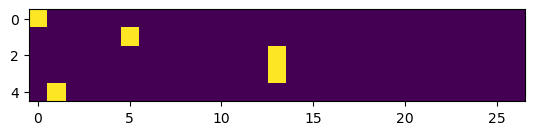

In [90]:
plt.imshow(xenc)

In [91]:
g = torch.Generator().manual_seed(2147483647)

W = torch.randn((27,27), generator=g)
logits = xenc @ W
count = logits.exp()
probs = count / count.sum(dim=1, keepdims=True)
probs

tensor([[0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
         0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
         0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459],
        [0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
         0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
         0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0150, 0.0086,

In [92]:
nlls = torch.zeros(5)

for i in range(5):
    x = xs[i].item()
    y = ys[i].item()
    print("--------")
    print(f"bigram example {i+1}: {itos[x]}{itos[y]} (indexs {x}{y})")
    print("input to the neural net:", x)
    print("output probablities from the neural net:", probs[i])
    print("label actual next character:", y)
    p = probs[i, y]
    print("probablity assigned by the net to the correct character:", p.item())
    logp = torch.log(p)
    print("log likelihood:", logp.item())
    nll = -logp
    print("negative log likelihood:", nll.item())
    nlls[i] = nll

print("=========")
print("average negative log likelihood, i.e. loss=", nlls.mean().item())

--------
bigram example 1: .e (indexs 05)
input to the neural net: 0
output probablities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label actual next character: 5
probablity assigned by the net to the correct character: 0.012286250479519367
log likelihood: -4.3992743492126465
negative log likelihood: 4.3992743492126465
--------
bigram example 2: em (indexs 513)
input to the neural net: 5
output probablities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label actual next character: 13
probablity assigned by the net to the correct character: 0.01805070415139198

In [93]:
xs

tensor([ 0,  5, 13, 13,  1])

In [94]:
ys

tensor([ 5, 13, 13,  1,  0])

In [95]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g)


In [98]:
# Forward pass

xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(dim=1, keepdims=True)

loss = -probs[torch.arange(5), ys].log().mean()
print(loss)


tensor(3.7693)


In [ ]:
# Backward pass
W.grad = None # set to zero the gradient
loss.backward()


W.data -= 0.1 * W.grad


tensor(3.7693)


In [108]:
x1, x2 = [], []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        stoi1 = stoi[ch1]
        stoi2 = stoi[ch2]
        x1.append(stoi1)
        x2.append(stoi2)

xs = torch.tensor(x1)
ys = torch.tensor(x2)
num = xs.numel()
print("numbers of examples:", num)

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g, requires_grad=True)

for k in range(50):

    W.grad = None

    # Forward pass
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(dim=1, keepdims=True)
    loss = -probs[torch.arange(num), ys].log().mean()
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01 * (W ** 2).mean()
    print(loss.item())

    # Backward pass
    loss.backward()

    # Update
    W.data -= 100 * W.grad


numbers of examples: 228146
3.76861834526062
3.1362504959106445
2.9207499027252197
2.8068220615386963
2.7409589290618896
2.694500207901001
2.6633121967315674
2.639400005340576
2.6313271522521973
2.6171419620513916
2.6260857582092285
2.59152889251709
2.5851943492889404
2.5777578353881836
2.591890335083008
2.563154935836792
2.562349796295166
2.5569393634796143
2.5732839107513428
2.546804189682007
2.5485079288482666
2.5443508625030518
2.561941623687744
2.5365195274353027
2.539466619491577
2.536151170730591
2.5545339584350586
2.529625415802002
2.5332159996032715
2.53048038482666
2.549400568008423
2.5247485637664795
2.528688430786133
2.5263612270355225
2.5456604957580566
2.5211451053619385
2.5252878665924072
2.5232532024383545
2.542827844619751
2.5183932781219482
2.522664785385132
2.5208420753479004
2.5406196117401123
2.516240119934082
2.5206000804901123
2.518932580947876
2.5388619899749756
2.514523983001709
2.5189497470855713
2.517396926879883


In [111]:
for i in range(5):

    out = []
    ix = 0
    while True:
        xenc = F.one_hot(torch.tensor(ix), num_classes = 27).float()
        logits = xenc @ W
        counts = logits.exp()
        p = counts / counts.sum()

        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix ==0:
            break
    print(''.join(out))

jigla.
sadryropriniydavesole.
rish.
be.
ka.
